# Agentic RAG with LangGraph

## The Final Step: From Pipeline to Agent

You have built every stage of a modern RAG system:

| Tutorial | What you built |
|----------|----------------|
| **1A** | Chunking strategies |
| **1B** | Query optimization & routing |
| **2A** | Core retrieval (vector, hybrid, reranking) |
| **2B** | Adaptive orchestration |
| **3** | Post-retrieval context preparation |
| **4** | Evaluation (classical + RAGAS metrics) |
| **5** | **Agentic RAG** ← you are here |

Tutorials 1-4 gave you a **linear pipeline**: every question flows through retrieve → prepare → generate. That works and you can measure it rigorously.

Production systems often need something more: an **LLM that decides** whether to search, how to search, and when to answer directly. That is **agentic RAG**.

![Agent Architecture](../../data/display_images/agent_architecture.jpg)

---

## The Challenge

Real users do not always need retrieval:

- **"Hi, what can you help with?"** → answer from the system prompt, no search
- **"What's a TPU for in ML infra?"** → rewrite if needed, then call retrieval
- **"Compare pandas vs polars for a 50MB CSV"** → search workshop papers, synthesize an answer

The techniques from Tutorials 1–4 still apply - they move **inside** a tool the agent can call (or skip).

---

## What You'll Learn

We build a minimal **LangGraph ReAct agent** with one retrieval tool:

1. **Agent fundamentals** - planner, tools, memory, and the ReAct loop
2. **RAG as a tool** - wrap `RAG.retrieve_context` behind `retrieve_workshop_docs`
3. **Prompt-based routing** - when to search vs answer directly (Tutorial 1B concepts, prompt-driven here)
4. **Lightweight agent eval** - did the agent pick the right tool? (full quality metrics stay in Tutorial 4)

**Intentionally simplified in this demo** (add inside the tool when you need them):
- Reranking (Tutorial 2A)
- Context preparation (Tutorial 3)

---

## Tutorial Structure

```
Setup
    ↓
Agent Concepts (what is an agent, components, tools)
    ↓
Part 1: Retrieval Tool
    ↓
Part 2: LangGraph ReAct Agent + System Prompt
    ↓
Part 3: Run the Agent (Try It)
    ↓
Part 4: Lightweight Tool-Selection Check
    ↓
Workshop Recap & Key Takeaways
```

All agent and tool code lives **in this notebook**. Let's build it.


## Setup

In [1]:
import warnings
import logging
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)

import json
from typing import Any, Dict, List, Union

from langchain_core.documents import Document
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from IPython.display import Image, display

from retrieval_playground.utils import config
from retrieval_playground.utils.model_manager import model_manager
from retrieval_playground.src.baseline_rag import RAG
from retrieval_playground.src.evaluation.tool_metrics import ToolEvaluator, ToolTrace

In [2]:
llm = model_manager.get_llm()
DEFAULT_COLLECTION = "recursive_character" 
RETRIEVE_K = 2
rag = RAG(strategy="recursive_character") # other available strategies: ["recursive", "contextual", "parent_child", "hybrid", "docling"]

AVAILABLE_COLLECTIONS = config.SUPPORTED_COLLECTIONS
pipeline_trace: List[Dict[str, Any]] = []


def _answer_text(content: Union[str, list]) -> str:
    """Normalize Gemini / LangChain message content to plain text."""
    if isinstance(content, str):
        return content
    if isinstance(content, list):
        parts = []
        for block in content:
            if isinstance(block, dict) and block.get("text"):
                parts.append(block["text"])
            elif isinstance(block, str):
                parts.append(block)
        return "".join(parts)
    return str(content)


def _format_docs(docs: List[Document]) -> str:
    if not docs:
        return "No documents found."
    blocks = []
    for doc in docs:
        source = doc.metadata.get("source", "unknown")
        blocks.append(f"[{source}]\n{doc.page_content[:600]}")
    return "\n\n---\n\n".join(blocks)

## What Is an Agent?

An **agent** is an LLM that can **act** - not just generate text, but choose actions, observe results, and iterate.

Compared to a fixed RAG chain:

| Fixed RAG pipeline | Agentic RAG |
|--------------------|-------------|
| Every query → retrieve → generate | LLM **decides** whether to retrieve |
| Same code path every time | Can loop: think → act → observe → answer |
| Routing is hard-coded or pre-hooks | Routing can live in the **prompt** or dedicated tools |

The core idea: **the LLM is the controller**, not just the answer generator.

---

## Agent Components

Most production agents combine four building blocks:

```
┌─────────────────────────────────────────────────────────┐
│                      LLM (Brain)                        │
│         reasons, plans, decides next action             │
└─────────────────────────┬───────────────────────────────┘
                          │
          ┌───────────────┼───────────────┐
          ▼               ▼               ▼
    ┌──────────┐   ┌──────────┐   ┌───────────────┐
    │  Tools   │   │  Memory  │   │ System prompt │
    │ (actions)│   │ (state)  │   │ (instructions)│
    └──────────┘   └──────────┘   └───────────────┘
```

| Component | Role in this notebook |
|-----------|------------------------|
| **LLM** | Gemini via `model_manager` - routes queries and writes answers |
| **Tools** | `retrieve_workshop_docs` - vector search over workshop PDFs |
| **Memory** | LangGraph message history within a single `invoke()` (conversation turns) |
| **System prompt** | Routing rules, query rewrite guidance, when *not* to search |

**ReAct** (Reason + Act) is the loop you will use: the model *reasons* in text, *acts* by calling a tool, *observes* the tool output, then produces a final answer.

---

## RAG as an Agent Tool

In Tutorials 1–4, RAG was the **whole system**. In agentic RAG, RAG becomes **one capability**:

```
User question
     │
     ▼
┌─────────┐     no tool needed      ┌──────────────┐
│  Agent  │ ──────────────────────► │ Direct reply │
│  (LLM)  │                         └──────────────┘
└────┬────┘
     │ calls retrieve_workshop_docs
     ▼
┌─────────────────────────────────────┐
│  Tool: embed → Qdrant search → k=2  │  ← Tutorials 1A-2A inside the tool
│  Return chunk text to the agent     │
└─────────────────────────────────────┘
     │
     ▼
 Agent synthesizes final answer from tool output
```

**Key insight:** chunking, routing, retrieval, post-retrieval prep, and evaluation do not disappear - they move **inside** or **behind** the tool.

---

## Tools: The Agent's Hands

A **tool** is a function the LLM can call with structured arguments. LangChain's `@tool` decorator gives the model a name, description, and schema so it knows *when* and *how* to invoke it.

Good tool design matters:

- **Clear docstring** - the model reads this to decide when to call the tool
- **Narrow scope** - one tool, one job (`retrieve_workshop_docs`, not `do_everything`)
- **Stable output** - return plain text the agent can cite in its answer

In the next section we wrap baseline vector RAG as exactly one tool.


## 1. Retrieval Tool (Vector RAG)

We expose Tutorials 1–2 retrieval as a single tool the agent can call:

1. **Embed the query** and search Qdrant (`recursive_character` collection)
2. **Return top-k chunks** as formatted text for the agent to read

Query routing and abbreviation expansion are handled in the **system prompt** (Part 2), not as separate tools - a common production pattern when you want one retrieval entry point.

> **Production extensions:** Add Tutorial 2A's `Reranker` or Tutorial 3's `ContextPreparer` *inside* this tool when you need better ordering or cleaner context, then measure impact in Tutorial 4.


In [3]:
@tool
def retrieve_workshop_docs(
    question: str,
    collection: str = DEFAULT_COLLECTION,
) -> str:
    """
    Retrieve workshop PDF chunks via vector search (Qdrant).

    Use for technical questions about the indexed workshop papers.
    Call once per user question; answer from the returned text.

    Args:
        question: Clear search query with abbreviations already expanded
            (e.g. 'tensor processing unit', not 'TPU').
        collection: Qdrant collection (chunking strategy). **Leave default** for
            normal workshop questions - all workshop PDFs use the default index.

            Valid values only:
              - recursive_character (default)
              - parent_child
              - contextual
              - docling
              - hybrid

            Do NOT use invented names like 'workshop_papers' or 'workshop'.
            Only set `collection` if the user explicitly names a chunking strategy.

    Returns:
        Chunk text with source filenames, or a no-results message.
    """
    if collection not in AVAILABLE_COLLECTIONS:
        pipeline_trace.append({
            "step": "collection_fallback",
            "invalid": collection,
            "used": DEFAULT_COLLECTION,
        })
        collection = DEFAULT_COLLECTION

    pipeline_trace.append({"tool": "retrieve_workshop_docs", "collection": collection})

    pairs = rag.retrieve_context(question, k=RETRIEVE_K, collection_name=collection)
    docs = [doc for doc, _ in pairs]
    pipeline_trace.append({"step": "vector_search", "count": len(docs)})
    return _format_docs(docs)


tools = [retrieve_workshop_docs]


## 2. LangGraph ReAct Agent + System Prompt

**LangGraph** compiles an agent graph: the LLM node can call tools, receive observations, and loop until it has enough context to answer.

The **system prompt** is your policy layer - it replaces separate pre-hooks for this demo:

| Tutorial 1B technique | Agentic equivalent here |
|-----------------------|-------------------------|
| `semantic_layer` routing | Prompt: greetings → no tool; technical → search |
| `expand_query` | Prompt: rewrite acronyms before searching |

The agent graph below shows the ReAct loop: LLM → (optional) tool → LLM → final answer.


In [4]:
AGENT_PROMPT = """You are a helpful assistant that can answer questions on ML and RAG based on supplied context.

## Routing
- Greetings, thanks, and meta questions ("what can you do?"): answer directly. Do NOT call any tool.
- Technical questions about workshop papers: call `retrieve_workshop_docs` exactly once, then answer from its output.

## Before searching
Rewrite the user's question into a clear search query (only if required) before calling the tool.
- Spell out abbreviations (ML → machine learning, TPU → tensor processing unit).
- Pass only `question`. Do NOT pass `collection` unless the user explicitly names a chunking strategy.

## Responses
- Base technical answers on retrieved documents.
- Cite source filenames when available.
- If no documents are found, say you could not find evidence in the workshop set.
"""

agent = create_react_agent(llm, tools, prompt=AGENT_PROMPT)

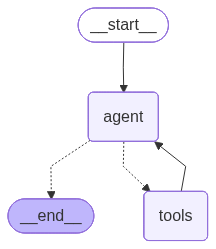

In [5]:
graph = agent.get_graph()
display(Image(graph.draw_mermaid_png()))

## 3. Run the Agent

Each `run_agent_query()` call sends a message through the graph. The agent either:

- **Answers directly** (greetings, meta questions about capabilities)
- **Calls `retrieve_workshop_docs`** then synthesizes an answer from returned chunks

There is no `semantic_layer()` pre-hook before the agent - compare this prompt-driven approach with Tutorial 1B's deterministic router.


In [6]:
def _tool_names_from_messages(messages) -> List[str]:
    names = []
    for msg in messages:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for call in msg.tool_calls:
                names.append(call["name"])
    return names


def run_agent_query(query: str, verbose: bool = True) -> Dict[str, Any]:
    """Invoke the agent; routing and query rewrite are handled by the system prompt."""
    global pipeline_trace
    pipeline_trace = []

    result = agent.invoke({"messages": [HumanMessage(content=query)]})
    messages = result["messages"]
    tools_used = _tool_names_from_messages(messages)
    answer = _answer_text(messages[-1].content)

    if verbose:
        print(f"Tools used: {tools_used or ['none (direct answer)']}")
        if pipeline_trace:
            print("Pipeline trace:", pipeline_trace)
        print()

    return {
        "query": query,
        "tools_used": tools_used,
        "answer": answer,
        "messages": messages,
        "pipeline_trace": pipeline_trace,
    }


### Try It

Run both cells below and compare behavior:

| Query type | Expected behavior |
|------------|-------------------|
| Greeting | Direct answer, **no** tool call |
| Technical workshop question | Calls `retrieve_workshop_docs`, then answers from chunks |


In [7]:
# Greeting — prompt should route to direct answer (no tool)
greeting_run = run_agent_query("Hi! What can you help me with?")
print("Answer:", greeting_run["answer"][:300])

Tools used: ['none (direct answer)']

Answer: Hello! I am a helpful assistant designed to help you with questions related to machine learning and Retrieval-Augmented Generation (RAG).

Specifically, I can:
*   **Answer technical questions** based on a collection of workshop papers. If you have a question about a specific research paper or techn


In [8]:
# Technical question — agent calls retrieve_workshop_docs
rag_run = run_agent_query("what's a TPU actually for in modern ML infra?")
print("Answer:")
print(rag_run["answer"])

Tools used: ['retrieve_workshop_docs']
Pipeline trace: [{'tool': 'retrieve_workshop_docs', 'collection': 'recursive_character'}, {'step': 'vector_search', 'count': 2}]

Answer:
In modern machine learning infrastructure, a **Tensor Processing Unit (TPU)** is a specialized hardware accelerator designed specifically to handle the intensive, repetitive matrix and tensor operations that form the backbone of deep learning models.

According to the provided documentation (*2024_GPU_CUDA_ML.pdf*), TPUs serve several key roles:

*   **High-Performance Training and Inference:** TPUs are highly effective for large-scale machine learning models, such as those used in natural language processing, computer vision, and large-scale recommendation systems. Their architecture is optimized to perform these specific mathematical operations faster and more efficiently than general-purpose processors like CPUs or GPUs.
*   **Efficiency through Reduced Precision:** TPUs often operate at lower precision forma

## 4. Lightweight Tool Check (Not Full Tutorial 4 Eval)

[Tutorial 4](4_Evaluation.ipynb) runs the **full metric stack** - Hit@k, RAGAS context precision, baseline vs post-retrieval, and more.

Agent systems need an **additional** signal: **did the model pick the right capability?**

| Check | Greeting | Technical question |
|-------|----------|-------------------|
| Expected tool | `none` | `retrieve_workshop_docs` |

We reuse the **Try it** runs above - no extra LLM calls. If the agent calls the wrong tool, tighten the system prompt or add deterministic routing from Tutorial 1B before the agent loop.


In [9]:
def _actual_tool(tools_used: List[str]) -> str:
    return tools_used[0] if tools_used else "none"


tool_traces = [
    ToolTrace(
        query="Hi! What can you help me with?",
        expected_tool="none",
        actual_tool=_actual_tool(greeting_run["tools_used"]),
    ),
    ToolTrace(
        query="what's a TPU actually for in modern ML infra?",
        expected_tool="retrieve_workshop_docs",
        actual_tool=_actual_tool(rag_run["tools_used"]),
    ),
]
for t in tool_traces:
    t.success = t.actual_tool == t.expected_tool

tool_eval = ToolEvaluator().evaluate(tool_traces)
print("Tool selection (2 demo queries):", round(tool_eval.scores["tool_selection_accuracy"], 2))
for row in tool_eval.details["tool_selection_accuracy"]:
    mark = "✅" if row["match"] else "❌"
    print(f"  {mark} expected={row['expected']} actual={row['actual']}")


Tool selection (2 demo queries): 1.0
  ✅ expected=none actual=none
  ✅ expected=retrieve_workshop_docs actual=retrieve_workshop_docs


---

## Workshop Recap: The Full RAG Lifecycle

You have walked the complete journey from raw PDFs to an agent that knows when to search:

```
Documents
    ↓  Tutorial 1A - Chunking
Index (Qdrant)
    ↓  Tutorial 1B - Query optimization & routing
Retrieval
    ↓  Tutorial 2A/2B - Vector, hybrid, reranking, orchestration
Post-Retrieval
    ↓  Tutorial 3 - Grading, refinement, compression
Generation
    ↓  Tutorial 4 - Measure every stage
Agentic RAG
    ↓  Tutorial 5 - LLM decides when & how to retrieve
```

---

## Key Takeaways

1. **Chunking is foundational** - retrieval quality starts with how you split documents (1A).
2. **Query transformation matters** - expand, decompose, or route before search (1B).
3. **Retrieval is not one algorithm** - combine vector search, hybrid, reranking, and orchestration (2A/2B).
4. **Context preparation changes answers** - grade, refine, and compress before generation (3).
5. **You cannot improve what you do not measure** - classical + RAGAS metrics per stage (4).
6. **Agents wrap the pipeline** - RAG becomes a tool; the LLM controls when it runs (5).

---

## Closing Note

You started with a simple question: *how do I get the right context to an LLM?*

You end with a system that **chunks intelligently, retrieves adaptively, prepares context carefully, measures rigorously, and decides autonomously when to search**.

That is the full modern RAG stack. The techniques compound - better chunks improve retrieval, better retrieval improves answers, evaluation tells you where to invest, and agents let users interact with the whole system naturally.